In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from numpy import meshgrid
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torch.autograd import gradcheck
from numpy import exp, mod, meshgrid, cos, sin, exp, pi
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import shift
from math import sqrt
from scipy.sparse import diags
from scipy.linalg import cholesky

import os
impath = "./data/Crossing_StraightCubic_waves/"
immpath = "./plots/Crossing_StraightCubic_waves/"
os.makedirs(impath, exist_ok=True)
os.makedirs(immpath, exist_ok=True)

# Crossing waves example

## Create data for example model

In [2]:
seed = 10
np.random.seed(seed)
torch.manual_seed(seed)

dtype  = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pretrained_load = True
print(device)

cpu


In [3]:
Nx, Nt = 400, 200
t_start = -10.0
t_end = 10.0

In [4]:
x = np.arange(0, Nx)
t = np.linspace(t_start, t_end, Nt)
x_device = torch.tensor(x.copy(),  dtype=dtype, device=device)
t_device = torch.tensor(t.copy(),  dtype=dtype, device=device)
coefficients1 = torch.tensor([0.15,0,0.8,1.5], dtype=dtype, device=device)
coefficients2 = torch.tensor([-18,2], dtype=dtype, device=device)
sigma = torch.tensor(4.0, dtype=dtype, device=device)
center_matrix = torch.tensor(200.0, dtype=dtype, device=device)

In [5]:
@torch.jit.script
def torch_polyval(coeffs, t_array):
    results = torch.zeros_like(t_array)
    for i in range(t_array.shape[0]):
        t = t_array[i]
        result = 0.0
        for coeff in coeffs:
            result = result * t + coeff
        results[i] = result
    return results


@torch.jit.script
def torch_gaussian(x, mu, sigma):
    return torch.exp(-torch.pow(x - mu, 2.0) / (2 * torch.pow(sigma, 2.0)))


def generate_data_crossing_wave(coefficients1, coefficients2, x, t, center_of_matrix, sigma):
    shift1 = torch_polyval(coefficients1, t)
    shift2 = torch_polyval(coefficients2, t)
    X1, MU1 = torch.meshgrid(x, center_of_matrix + shift1)
    X2, MU2 = torch.meshgrid(x, center_of_matrix + shift2)
    
    Q1 = torch_gaussian(X1, MU1, sigma)
    Q2 = torch_gaussian(X2, MU2, sigma)
    
    Q = Q1 + Q2

    return Q, Q1, Q2, shift1, shift2

In [6]:
Q, Q1, Q2, shift1, shift2 = generate_data_crossing_wave(coefficients1, coefficients2, x_device, t_device, center_matrix, sigma)

/Users/shubhadityaburela/miniforge3/envs/pytorch_gpu_new/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


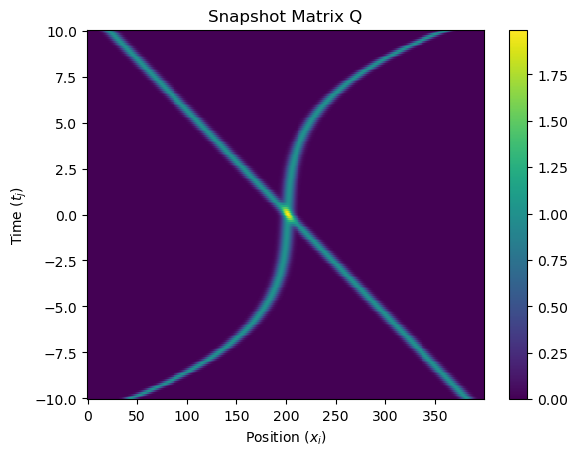

In [7]:
X, T = np.meshgrid(x, t)
plt.pcolormesh(X.T, T.T, Q)
plt.colorbar()
plt.xlabel('Position ($x_i$)')
plt.ylabel('Time ($t_j$)')
plt.title('Snapshot Matrix Q')
plt.show()

## Define a model

In [8]:
@torch.jit.script
def nuclear_norm(input_matrix: torch.Tensor) -> torch.Tensor:
    # Forward computation
    return torch.linalg.matrix_norm(input_matrix, ord="nuc")


@torch.jit.script
def nuclear_norm_grad(input_matrix: torch.Tensor, grad_output: torch.Tensor) -> torch.Tensor:
    u, s, v = torch.linalg.svd(input_matrix, full_matrices=False)
    rank = (s > 0).sum().item()
    eye_approx = torch.diag_embed((s > 0).to(input_matrix.dtype)[:rank])
    grad_input = torch.matmul(u[:, :rank], eye_approx)
    grad_input = torch.matmul(grad_input, v[:, :rank].transpose(-2, -1))
    return grad_input * grad_output.unsqueeze(-1).unsqueeze(-1)


class NuclearNormAutograd(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_matrix):
        ctx.save_for_backward(input_matrix)
        return nuclear_norm(input_matrix)

    @staticmethod
    def backward(ctx, grad_output):
        input_matrix, = ctx.saved_tensors
        return nuclear_norm_grad(input_matrix, grad_output)

In [9]:
class ShapeShiftNet(nn.Module):
    def __init__(self, N_in, N_in_c, N_out, N_out_c, N_hidden, N_layers, x, t, center_matrix):
        super(ShapeShiftNet, self).__init__()
        
        self.register_buffer('x_flat', x)
        self.register_buffer('t_flat', t)
        self.register_buffer('center_matrix', center_matrix)
        
        activation = torch.nn.Tanh
        
        # network for f^1
        self.fc_in_frame1 = torch.nn.Sequential(*[torch.nn.Linear(N_in, N_hidden), activation()])
        # Hidden layers.
        self.hidden_layers_frame1 = torch.nn.Sequential(*[torch.nn.Sequential(*[torch.nn.Linear(N_hidden, N_hidden), activation()]) 
                                                          for _ in range(N_layers - 1)])
        # Output layer.
        self.fc_out_frame1 = torch.nn.Linear(N_hidden, N_out)

        
        # network for f^2
        self.fc_in_frame2 = torch.nn.Sequential(*[torch.nn.Linear(N_in, N_hidden), activation()])
        # Hidden layers.
        self.hidden_layers_frame2 = torch.nn.Sequential(*[torch.nn.Sequential(*[torch.nn.Linear(N_hidden, N_hidden), activation()]) 
                                                          for _ in range(N_layers - 1)])
        # Output layer.
        self.fc_out_frame2 = torch.nn.Linear(N_hidden, N_out)


        # Shift 1
        # Input layer.
        self.shift_in1 = torch.nn.Sequential(*[torch.nn.Linear(N_in_c, N_hidden), activation()])
        # Hidden layers.
        self.hidden_layers1 = torch.nn.Sequential(*[torch.nn.Sequential(*[torch.nn.Linear(N_hidden, N_hidden), activation()]) 
                                                          for _ in range(N_layers - 1)])
        # Output layer.
        self.shift_out1 = torch.nn.Linear(N_hidden, N_out_c)


        # Shift 2
        # Input layer.
        self.shift_in2 = torch.nn.Sequential(*[torch.nn.Linear(N_in_c, N_hidden), activation()])
        # Hidden layers.
        self.hidden_layers2 = torch.nn.Sequential(*[torch.nn.Sequential(*[torch.nn.Linear(N_hidden, N_hidden), activation()]) 
                                                          for _ in range(N_layers - 1)])
        # Output layer.
        self.shift_out2 = torch.nn.Linear(N_hidden, N_out_c)

        
    def forward(self):
        ################################ Shifts ####################################
        c1 = self.shift_in1(self.t_flat)
        for layer in self.hidden_layers1:
            c1 = layer(c1)
        c1 = self.shift_out1(c1)

        c2 = self.shift_in2(self.t_flat)
        for layer in self.hidden_layers2:
            c2 = layer(c2)
        c2 = self.shift_out2(c2)

        ################################ Frames ####################################
        x_shifted1 = self.x_flat - c1 * self.t_flat - self.center_matrix
        f1 = self.fc_in_frame1(torch.cat((x_shifted1, self.t_flat), dim=1))
        for layer in self.hidden_layers_frame1:
            f1 = layer(f1)
        f1 = self.fc_out_frame1(f1)

        x_shifted2 = self.x_flat - c2 * self.t_flat - self.center_matrix
        f2 = self.fc_in_frame2(torch.cat((x_shifted2, self.t_flat), dim=1))
        for layer in self.hidden_layers_frame2:
            f2 = layer(f2)
        f2 = self.fc_out_frame2(f2)



        f1_without_shift = self.fc_in_frame1(torch.cat((self.x_flat - self.center_matrix, self.t_flat), dim=1))
        for layer in self.hidden_layers_frame1:
            f1_without_shift = layer(f1_without_shift)
        f1_without_shift = self.fc_out_frame1(f1_without_shift)

        f2_without_shift = self.fc_in_frame2(torch.cat((self.x_flat - self.center_matrix, self.t_flat), dim=1))
        for layer in self.hidden_layers_frame2:
            f2_without_shift = layer(f2_without_shift)
        f2_without_shift = self.fc_out_frame2(f2_without_shift)
        
        return f1, f2, c1, c2, f1_without_shift, f2_without_shift

## Define inputs

In [10]:
x_flat = (x_device).repeat_interleave(Nt).to(device=device, dtype=dtype).view(-1, 1)
t_flat = (t_device).repeat(Nx).to(device=device, dtype=dtype).view(-1, 1)
Q = torch.tensor(Q, dtype=dtype, device=device)

lr = 0.0005
num_epochs = 75000
lambda_star = 0.005

/var/folders/ys/rspl6b551rl9f5w6r8yffqv40000gn/T/ipykernel_38766/2553950029.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Q = torch.tensor(Q, dtype=dtype, device=device)


## Call the model

In [11]:
model = ShapeShiftNet(2, 1, 1, 1, 32, 4, x_flat, t_flat, center_matrix)

if pretrained_load:
    state_dict_original = torch.load("./data/Crossing_StraightCubic_waves/Crossing_StraightCubic_waves.pth", map_location=torch.device('cpu'))
    state_dict_new = model.state_dict()
    
    for name, param in state_dict_original.items():
        if name in state_dict_new:
            state_dict_new[name].copy_(param)
    model.load_state_dict(state_dict_new, strict=False)
    jit_model = torch.jit.script(model)
    jit_model.to(device)
    delta = 1e-1
else:
    jit_model = torch.jit.script(model)
    jit_model.to(device)
    delta = 1e-5

optimizer = torch.optim.Adam(jit_model.parameters(), lr=lr)

/var/folders/ys/rspl6b551rl9f5w6r8yffqv40000gn/T/ipykernel_38766/521872800.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict_original = torch.load("./data/Strai

In [12]:
for epoch in range(num_epochs + 1):
    optimizer.zero_grad()

    # Function call for the model
    f1_full, f2_full, shift1_pred, shift2_pred, f1_full_nos, f2_full_nos = jit_model()
    T1Q1 = f1_full.view(Nx, Nt)
    T2Q2 = f2_full.view(Nx, Nt)
    Q1 = f1_full_nos.view(Nx, Nt)
    Q2 = f2_full_nos.view(Nx, Nt)
    
    frobenius_loss = torch.linalg.norm(Q - T1Q1 - T2Q2, 'fro')/ torch.linalg.norm(Q, 'fro')
    nuclear_loss = lambda_star * (NuclearNormAutograd.apply(Q1) + NuclearNormAutograd.apply(Q2))
    total_loss = frobenius_loss + nuclear_loss

    total_loss.backward()
    
    optimizer.step()

    if frobenius_loss < delta:
        print("Early stopping is triggered")
        break
    with torch.no_grad():
        if epoch % 10 == 0:
            print("\n**************************************************************")
            print(f'Epoch {epoch}/{num_epochs}, F: {frobenius_loss.item():.4f}, '
                  f'N: {nuclear_loss.item():.4f}, '
                  f'T: {total_loss.item():.4f}')

Early stopping is triggered


In [13]:
# Bring everything back to CPU
Q = Q.cpu().detach().numpy()
Q_tilde = (T1Q1 + T2Q2).cpu().detach().numpy()
T1Q1 = T1Q1.cpu().detach().numpy()
T2Q2 = T2Q2.cpu().detach().numpy()
Q1 = Q1.cpu().detach().numpy()
Q2 = Q2.cpu().detach().numpy()
shift1 = shift1.cpu().detach().numpy()
shift2 = shift2.cpu().detach().numpy()
shift1_numpy = shift1_pred.cpu().detach().numpy()
shift2_numpy = shift2_pred.cpu().detach().numpy()
shift1_numpy_mat = shift1_numpy.reshape(Nx, Nt)
shift2_numpy_mat = shift2_numpy.reshape(Nx, Nt)
shift1_pred = shift1_numpy * t_flat.cpu().detach().numpy()
shift2_pred = shift2_numpy * t_flat.cpu().detach().numpy()
shift1_pred_mat = shift1_pred.reshape(Nx, Nt)
shift2_pred_mat = shift2_pred.reshape(Nx, Nt)
shift1_val = shift1_pred_mat.max(axis=0)
shift2_val = shift2_pred_mat.max(axis=0)

RecErr: 0.013470952399075031


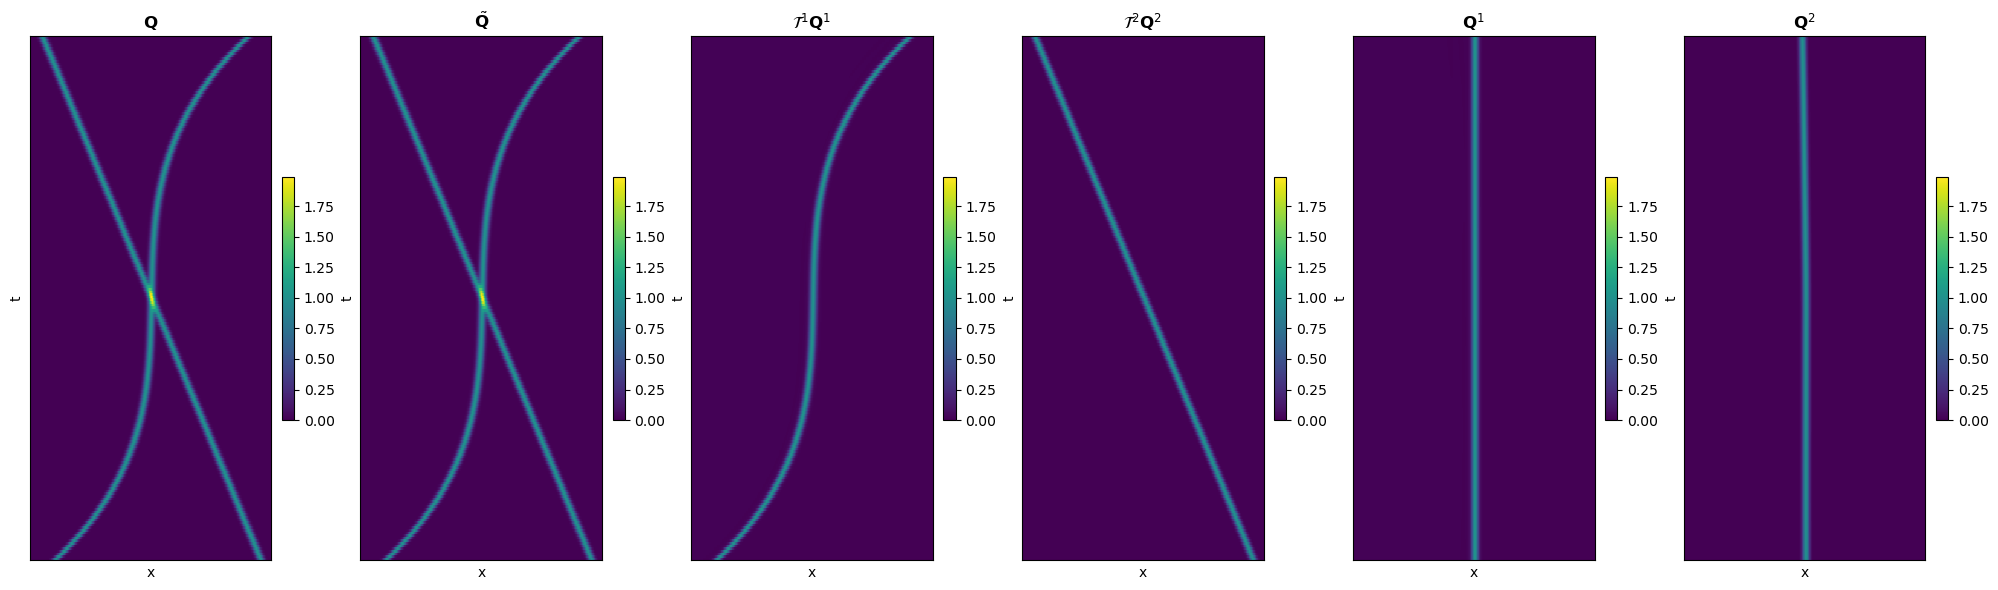

In [14]:
fig, axs = plt.subplots(1, 6, figsize=(20, 6))
vmin = np.min(Q)
vmax = np.max(Q)

im0 = axs[0].pcolormesh(X.T, T.T, Q, vmin=vmin, vmax=vmax)
axs[0].set_title(r"${\mathbf{Q}}$")
axs[0].set_xlabel("x")
axs[0].set_ylabel("t")
axs[0].set_xticks([])
axs[0].set_yticks([])
cbar0 = fig.colorbar(im0, ax=axs[0], orientation="vertical", fraction=0.046, pad=0.04)

#Qtilde
im1 = axs[1].pcolormesh(X.T, T.T, Q_tilde, vmin=vmin, vmax=vmax)
axs[1].set_title(r"$\tilde{\mathbf{Q}}$")
axs[1].set_xlabel("x")
axs[1].set_ylabel("t")
axs[1].set_xticks([])
axs[1].set_yticks([])
cbar1 = fig.colorbar(im1, ax=axs[1], orientation="vertical", fraction=0.046, pad=0.04)

# T^1Q^1
im2 = axs[2].pcolormesh(X.T, T.T, T1Q1, vmin=vmin, vmax=vmax)
axs[2].set_title(r"$\mathcal{T}^1\mathbf{Q}^1$")
axs[2].set_xlabel("x")
axs[2].set_ylabel("t")
axs[2].set_xticks([])
axs[2].set_yticks([])
cbar2 = fig.colorbar(im2, ax=axs[2], orientation="vertical", fraction=0.046, pad=0.04)

# T^2Q^2
im3 = axs[3].pcolormesh(X.T, T.T, T2Q2, vmin=vmin, vmax=vmax)
axs[3].set_title(r"$\mathcal{T}^2\mathbf{Q}^2$")
axs[3].set_xlabel("x")
axs[3].set_ylabel("t")
axs[3].set_xticks([])
axs[3].set_yticks([])
cbar3 = fig.colorbar(im3, ax=axs[3], orientation="vertical", fraction=0.046, pad=0.04)

# Q^1
im4 = axs[4].pcolormesh(X.T, T.T, Q1, vmin=vmin, vmax=vmax)
axs[4].set_title(r"$\mathbf{Q}^1$")
axs[4].set_xlabel("x")
axs[4].set_ylabel("t")
axs[4].set_xticks([])
axs[4].set_yticks([])
cbar4 = fig.colorbar(im4, ax=axs[4], orientation="vertical", fraction=0.046, pad=0.04)

# Q^2
im5 = axs[5].pcolormesh(X.T, T.T, Q2, vmin=vmin, vmax=vmax)
axs[5].set_title(r"$\mathbf{Q}^2$")
axs[5].set_xlabel("x")
axs[5].set_ylabel("t")
axs[5].set_xticks([])
axs[5].set_yticks([])
cbar5 = fig.colorbar(im5, ax=axs[5], orientation="vertical", fraction=0.046, pad=0.04)


fig.tight_layout()
fig.savefig(immpath + "Q_opti", dpi=300, transparent=True)

rec_err = np.linalg.norm(Q - T1Q1 - T2Q2) / np.linalg.norm(Q)
print(f"RecErr: {rec_err}")

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/var/folders/ys/rspl6b551rl9f5w6r8yffqv40000gn/T/ipykernel_38766/2576621110.py:2: SyntaxWarning: invalid escape sequence '\m'
  axs.plot(t, shift1_val, label="Predicted shift ($\mathcal{T}^1$)")
/var/folders/ys/rspl6b551rl9f5w6r8yffqv40000gn/T/ipykernel_38766/2576621110.py:3: SyntaxWarning: invalid escape sequence '\m'
  axs.plot(t, shift1, label="True shift ($\mathcal{T}^1$)")
/var/folders/ys/rspl6b551rl9f5w6r8yffqv40000gn/T/ipykernel_38766/2576621110.py:4: SyntaxWarning: invalid escape sequence '\m'
  axs.plot(t, shift2_val, label="Predicted shift ($\mathcal{T}^2$)")
/var/folders/ys/rspl6b55

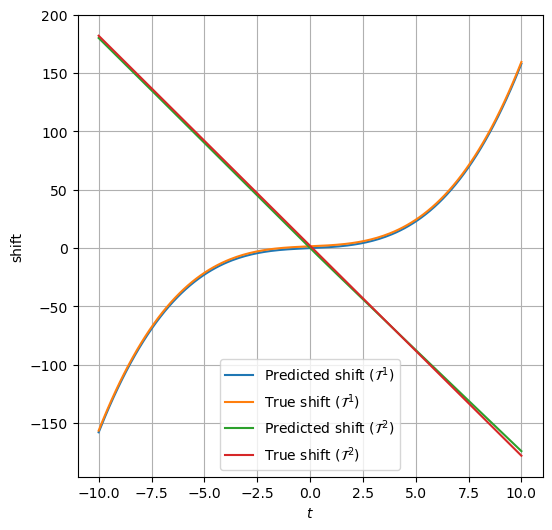

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(6, 6))
axs.plot(t, shift1_val, label="Predicted shift ($\mathcal{T}^1$)")
axs.plot(t, shift1, label="True shift ($\mathcal{T}^1$)")
axs.plot(t, shift2_val, label="Predicted shift ($\mathcal{T}^2$)")
axs.plot(t, shift2, label="True shift ($\mathcal{T}^2$)")
axs.set_ylabel(r"shift")
axs.set_xlabel(r"$t$")
axs.grid()
axs.legend()
plt.show()

## Saving the results

In [ ]:
torch.save(model.state_dict(), impath + 'Crossing_StraightCubic_waves.pth')
np.save(impath + 'Q.npy', Q)
np.save(impath + 'Q_tilde.npy', Q_tilde)
np.save(impath + 'T1Q1.npy', T1Q1)
np.save(impath + 'T2Q2.npy', T2Q2)
np.save(impath + 'Q1.npy', Q1)
np.save(impath + 'Q2.npy', Q2)
np.save(impath + 'shifts1.npy', shift1_val) 
np.save(impath + 'shifts2.npy', shift2_val) 
np.save(impath + 'shifts1_true.npy', shift1)
np.save(impath + 'shifts2_true.npy', shift2)